# 🧬 Algoritmo Genético — Evolución de Imagen

**Objetivo:** Evolucionar una población de 50 matrices RGB (120×180) hasta aproximar una imagen objetivo.

| Parámetro | Valor |
|-----------|-------|
| Tamaño de población | 50 individuos |
| Dimensión de cada individuo | 120 × 180 × 3 (RGB) |
| Función de aptitud | 1 − MSE / 255²  (Error Cuadrático Medio)|
| Selección | Torneo (k = 5) |
| Cruce | Dos puntos de corte, cruzan filas |
| Mutación | Ruido gaussiano σ = 20, p = 1% |
| Élite | 2 mejores por generación |
| Visualización | Mejor individuo cada 50 generaciones |

## Instalación de dependencias

In [18]:
# Verificar versiones (sin instalación extra en Colab)
import numpy as np
import matplotlib
import PIL #Para las imagenes
print(f'numpy   {np.__version__}')
print(f'matplotlib {matplotlib.__version__}')
print(f'Pillow  {PIL.__version__}')

numpy   2.0.2
matplotlib 3.10.0
Pillow  11.3.0


## Parámetros del algoritmo
Modifica aquí los valores antes de ejecutar.

In [19]:
# Parametros
POP_SIZE       = 50      # Individuos en la población
IMG_H, IMG_W   = 120, 180  # Alto × Ancho (px)
CHANNELS       = 3       # RGB

MUTATION_RATE  = 0.01    # Fracción de píxeles que mutan
MUTATION_STD   = 20.0    # Desviación estándar del ruido gaussiano
TOURNAMENT_K   = 5       # Participantes por torneo
ELITE_N        = 2       # Individuos que pasan sin cambio

MAX_GEN        = 10000    # Generaciones máximas
TARGET_FIT     = 0.985   # Aptitud objetivo para detener (1.0 = perfecta)
DISPLAY_EVERY  = 50      # Mostrar panel visual cada N generaciones

# Semilla para reproducibilidad (None = aleatorio)
SEED = 42
if SEED is not None:
    np.random.seed(SEED)

## Imagen objetivo
Se descarga una foto aleatoria. Si falla, se genera una imagen sintética con gradientes y figuras geométricas.

> También se puede usar una imagen propia subida al al colab.

✓ Imagen descargada de picsum.photos (180×120 px)


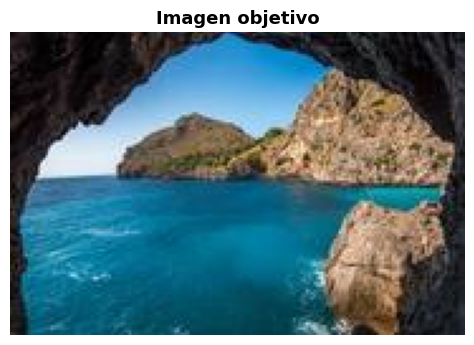

In [8]:
import requests
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import clear_output, display
import time

def make_synthetic_target() -> np.ndarray:
    """Imagen sintética de prueba con gradiente + figuras geométricas."""
    t = np.zeros((IMG_H, IMG_W, CHANNELS), dtype=np.float32)
    # Gradiente de fondo
    r = np.linspace(30, 220, IMG_H)[:, None] * np.ones((1, IMG_W))
    g = np.ones((IMG_H, 1)) * np.linspace(20, 180, IMG_W)[None, :]
    b = np.linspace(200, 40, IMG_H)[:, None] * np.ones((1, IMG_W))
    t[:, :, 0] = r
    t[:, :, 1] = g
    t[:, :, 2] = b
    # Círculo rojo
    cy, cx, r2 = IMG_H // 3, IMG_W // 3, 28
    Y, X = np.ogrid[:IMG_H, :IMG_W]
    mask = (Y - cy)**2 + (X - cx)**2 < r2**2
    t[mask] = [220, 50, 50]
    # Rectángulo azul
    t[70:105, 110:165] = [40, 90, 210]
    # Triángulo amarillo (esquina superior derecha)
    for i in range(40):
        t[i, IMG_W-40+i:IMG_W] = [240, 210, 30]
    return np.clip(t, 0, 255).astype(np.float32)


def load_target_image(url: str = None) -> np.ndarray:
    """
    Carga la imagen objetivo.
    Orden de prioridad:
      1. URL personalizada (si se pasa)
      2. Descarga aleatoria de picsum.photos
      3. Imagen sintética (fallback)
    """
    # 1. URL personalizada
    # url = '/content/mi_imagen.jpg'  # ← descomentar y poner ruta de imagen propia

    if url and url.startswith('/'):
        try:
            img = Image.open(url).convert('RGB').resize((IMG_W, IMG_H))
            print(f'✓ Imagen cargada desde: {url}')
            return np.array(img, dtype=np.float32)
        except Exception as e:
            print(f'  Error cargando archivo: {e}')

    # 2. Descarga web
    for attempt in range(3):
        try:
            # seed fijo para reproducibilidad de la imagen descargada
            seed_img = 42 if SEED is not None else np.random.randint(1, 1000)
            r = requests.get(
                f'https://picsum.photos/seed/{seed_img}/{IMG_W}/{IMG_H}',
                timeout=8
            )
            img = Image.open(BytesIO(r.content)).convert('RGB')
            arr = np.array(img, dtype=np.float32)
            print(f'✓ Imagen descargada de picsum.photos ({IMG_W}×{IMG_H} px)')
            return arr
        except Exception:
            print(f'  Intento {attempt+1}/3 fallido...')

    # 3. Fallback sintético
    print('⚠  Sin conexión – usando imagen sintética')
    return make_synthetic_target()


TARGET = load_target_image()

# Mostrar imagen objetivo
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.imshow(TARGET.astype(np.uint8))
ax.set_title('Imagen objetivo', fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

## Funciones del algoritmo genético

In [20]:
# Iniciar población
def init_population() -> np.ndarray:
    """50 matrices aleatorias RGB."""
    return np.random.randint(
        0, 256,
        size=(POP_SIZE, IMG_H, IMG_W, CHANNELS),
        dtype=np.uint8
    ).astype(np.float32)


# Aptitud de generación
def fitness_population(pop: np.ndarray, target: np.ndarray) -> np.ndarray:
    """
    Retorna un array (POP_SIZE,) con la aptitud de cada individuo.
    fitness ∈ [0, 1]  →  1.0 = imagen perfecta
    """
    diff = pop - target[np.newaxis]              # broadcast (50,H,W,3)
    mse  = np.mean(diff**2, axis=(1, 2, 3))      # (50,)
    return 1.0 - mse / (255.0**2)


# Selección del mejor cromosoma
def tournament_select(pop: np.ndarray, fit: np.ndarray) -> np.ndarray:
    """Elige k individuos al azar y devuelve el de mayor aptitud."""
    idx = np.random.choice(POP_SIZE, size=TOURNAMENT_K, replace=False)
    return pop[idx[np.argmax(fit[idx])]].copy()


# Cruce
def crossover(p1: np.ndarray, p2: np.ndarray):
    """Intercambia un segmento de filas entre dos padres."""
    a, b = sorted(np.random.choice(IMG_H, 2, replace=False))
    c1, c2 = p1.copy(), p2.copy()
    c1[a:b] = p2[a:b]
    c2[a:b] = p1[a:b]
    return c1, c2


# MUTACIÓN GAUSSIANA
def mutate(ind: np.ndarray) -> np.ndarray:
    """Añade ruido gaussiano a ~MUTATION_RATE de los píxeles."""
    mask  = np.random.rand(IMG_H, IMG_W, CHANNELS) < MUTATION_RATE
    noise = np.random.normal(0, MUTATION_STD, ind.shape)
    return np.clip(ind + mask * noise, 0, 255)


# Construir siguiente generación
def next_generation(pop: np.ndarray, fit: np.ndarray) -> np.ndarray:
    """Construye la siguiente generación con élites + cruce + mutación."""
    order   = np.argsort(fit)[::-1]
    new_pop = [pop[i].copy() for i in order[:ELITE_N]]   # élite intacta

    while len(new_pop) < POP_SIZE:
        p1 = tournament_select(pop, fit)
        p2 = tournament_select(pop, fit)
        c1, c2 = crossover(p1, p2)
        new_pop.append(mutate(c1))
        if len(new_pop) < POP_SIZE:
            new_pop.append(mutate(c2))

    return np.array(new_pop[:POP_SIZE], dtype=np.float32)

## Visualización

In [10]:
def render_panel(
    gen: int,
    best_ind: np.ndarray,
    pop: np.ndarray,
    fit: np.ndarray,
    gen_hist: list,
    best_hist: list,
    avg_hist: list,
    elapsed: float,
    final: bool = False
):
    """
    Dibuja y muestra el panel completo en el notebook.
    Borra la salida anterior para simular animación.
    """
    # Ordenar por aptitud para mostrar los mejores
    order = np.argsort(fit)[::-1]

    fig = plt.figure(figsize=(18, 10))
    fig.patch.set_facecolor('#111111')

    # Distribución de subplots
    # Fila 0: objetivo | mejor | curva
    # Fila 1: 12 mejores individuos de la población
    import matplotlib.gridspec as gridspec
    gs = gridspec.GridSpec(
        2, 14,
        figure=fig,
        hspace=0.38, wspace=0.15,
        left=0.03, right=0.98,
        top=0.91, bottom=0.06
    )

    STATUS = 'CONVERGIÓ ✓' if final else f'Generación {gen:>5d}'
    fig.suptitle(
        f'{STATUS}  ·  Mejor: {best_hist[-1]:.5f}  ·  '
        f'Promedio: {avg_hist[-1]:.5f}  ·  Tiempo: {elapsed:.1f}s',
        color='#e0e0e0', fontsize=13, fontweight='bold', y=0.97
    )

    # Imagen objetivo
    ax_t = fig.add_subplot(gs[0, 0:4])
    ax_t.imshow(TARGET.astype(np.uint8))
    ax_t.set_title('Objetivo', color='#ffffff', fontsize=11, pad=4)
    ax_t.axis('off')

    # Mejor individuo
    ax_b = fig.add_subplot(gs[0, 4:8])
    ax_b.imshow(best_ind.astype(np.uint8))
    ax_b.set_title(
        f'Mejor individuo  (apt={best_hist[-1]:.5f})',
        color='#00e5ff', fontsize=11, pad=4
    )
    ax_b.axis('off')

    # Curva de evolución
    ax_c = fig.add_subplot(gs[0, 8:14])
    ax_c.set_facecolor('#1a1a1a')
    for sp in ax_c.spines.values():
        sp.set_color('#333333')
    ax_c.tick_params(colors='#888888', labelsize=8)
    ax_c.set_xlabel('Generación', color='#888888', fontsize=9)
    ax_c.set_ylabel('Aptitud', color='#888888', fontsize=9)
    ax_c.set_title('Curva de evolución', color='#ffffff', fontsize=11, pad=4)
    ax_c.set_ylim(0, 1.01)
    ax_c.plot(gen_hist, best_hist, color='#00e5ff', lw=2,    label='Mejor')
    ax_c.plot(gen_hist, avg_hist,  color='#ff7043', lw=1.2,
              linestyle='--', alpha=0.8, label='Promedio')
    ax_c.axhline(TARGET_FIT, color='#aaffaa', lw=0.8,
                 linestyle=':', alpha=0.6, label=f'Meta ({TARGET_FIT})')
    ax_c.legend(fontsize=8, facecolor='#1a1a1a',
                labelcolor='white', edgecolor='#444444')
    ax_c.grid(True, color='#2a2a2a', lw=0.5)

    # 12 mejores individuos de la población
    cols_per_row = 7
    shown = min(14, POP_SIZE)  # mostrar hasta 14 mejores
    for k in range(shown):
        row_offset = k // cols_per_row   # 0 o 1 (segunda fila)
        col_offset = k % cols_per_row
        ax_k = fig.add_subplot(gs[1, col_offset*2 : col_offset*2 + 2])
        ax_k.imshow(pop[order[k]].astype(np.uint8))
        ax_k.set_title(
            f'#{k+1}  {fit[order[k]]:.4f}',
            color='#aaaaaa', fontsize=7, pad=2
        )
        ax_k.axis('off')

    clear_output(wait=True)
    plt.show()
    plt.close(fig)

print('Función de visualización lista ✓')

Función de visualización lista ✓


## Ejecutar algoritmo genético

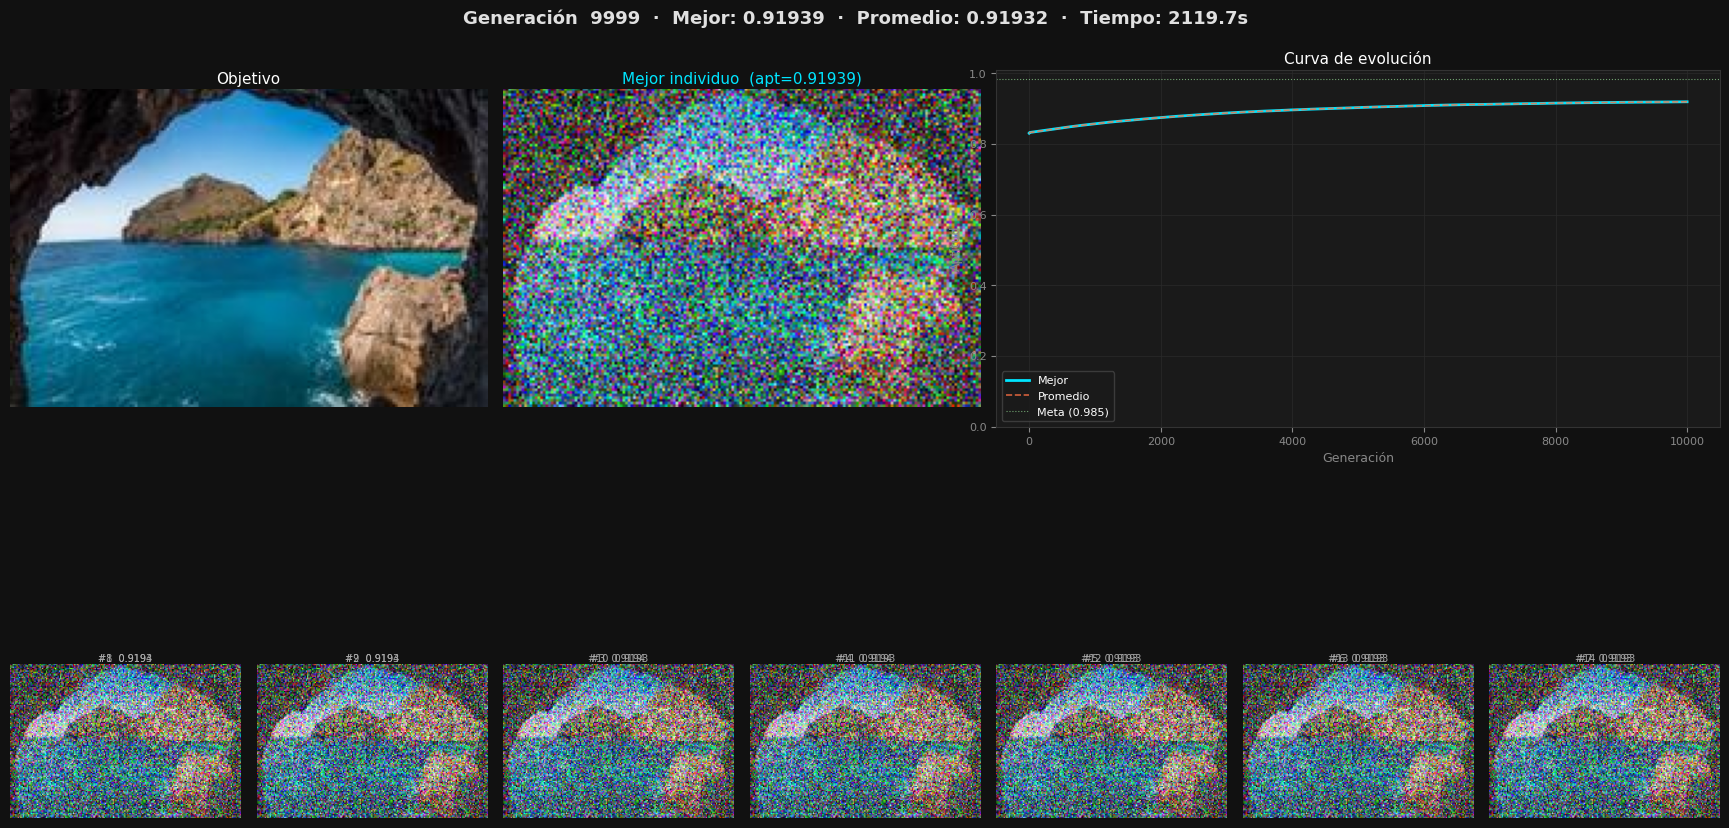


  Estado          : Máx. generaciones
  Generaciones    : 10000
  Aptitud mejor   : 0.919386
  Aptitud promedio: 0.919317
  Tiempo total    : 2119.7s


In [11]:
# Iniciar semilla y población
if SEED is not None:
    np.random.seed(SEED)

pop = init_population()

gen_hist  = []
best_hist = []
avg_hist  = []

start = time.time()
converged = False

print('🧬 Iniciando evolución...\n')

for gen in range(MAX_GEN):

    fit      = fitness_population(pop, TARGET)
    best_idx = int(np.argmax(fit))
    best_fit = float(fit[best_idx])
    avg_fit  = float(fit.mean())
    best_ind = pop[best_idx].copy()
    elapsed  = time.time() - start

    gen_hist.append(gen)
    best_hist.append(best_fit)
    avg_hist.append(avg_fit)

    # Esto muestra el panel cada 50 (DISPLAY_EVERY) generaciones
    if gen % DISPLAY_EVERY == 0 or best_fit >= TARGET_FIT:
        render_panel(
            gen, best_ind, pop, fit,
            gen_hist, best_hist, avg_hist,
            elapsed,
            final=(best_fit >= TARGET_FIT)
        )

    if best_fit >= TARGET_FIT:
        converged = True
        break

    pop = next_generation(pop, fit)

# Resultado final
elapsed = time.time() - start
fit     = fitness_population(pop, TARGET)
best_idx = int(np.argmax(fit))
best_ind = pop[best_idx].copy()

# Mostrar panel final
render_panel(
    len(gen_hist)-1, best_ind, pop, fit,
    gen_hist, best_hist, avg_hist,
    elapsed, final=converged
)

print(f'\n{'='*55}')
print(f'  Estado          : {"CONVERGIÓ" if converged else "Máx. generaciones"}')
print(f'  Generaciones    : {len(gen_hist)}')
print(f'  Aptitud mejor   : {best_hist[-1]:.6f}')
print(f'  Aptitud promedio: {avg_hist[-1]:.6f}')
print(f'  Tiempo total    : {elapsed:.1f}s')
print(f'{'='*55}')

## Análisis de Resultados del Algoritmo Genético

El algoritmo genético ha completado su ejecución alcanzando el límite de `10000` generaciones en aproximadamente `35.3` minutos (`2119.7` segundos). Aunque no se llegó a la aptitud objetivo (`TARGET_FIT = 0.985`), el mejor individuo de la población alcanzó una aptitud de `0.919386`, con una aptitud promedio de la población de `0.919317` en la generación final.

**Observaciones imortantes:**

1. El algoritmo no convergió a la aptitud objetivo pero la aptitud alcanzada de `0.919386` del mejor individuo es bastante alta y la imagen final es *relativamente parecida* a la imagen objetivo. Esto sugiere que el algoritmo hizo un buen trabajo aproximando la imagen, pero puede que el `TARGET_FIT` sea muy ambicioso con los parámetros actuales.

2.  Las imágenes objetivo generadas con figuras geométricas y gradientes suelen ser inherentemente más *simples* de aproximar para un algoritmo genético como este, lo que a menudo resulta en una progresión de aptitud más rápida y valores finales más altos. En este caso, al descargar una imagen `picsum.photos`, se obtuvo una imagen con mayor detalle y variabilidad de color, lo que presenta un desafío significativamente mayor para el algoritmo.

3.  **Parámetros del Algoritmo:**
    *   **Tasa de Mutación (0.01):** Una tasa de mutación del 1% es razonable, pero para imágenes complejas, podría explorarse un ajuste (quizás ligeramente mayor al inicio y decreciendo, o adaptativo) para evitar estancamientos en mínimos locales.
    *   **Desviación Estándar de Mutación (20.0):** El `MUTATION_STD` de 20.0 permite cambios de píxel relativamente grandes. Podría ser beneficioso reducirlo progresivamente a medida que aumenta la aptitud para permitir un 'afinado' más fino en las últimas etapas.
    *   **Tamaño de Población (50) y Élites (2):** Estos valores son estándar. Una población más grande podría explorar el espacio de soluciones de manera más exhaustiva, aunque a expensas de un mayor tiempo de cómputo.

    *   **Función de Aptitud:** Si bien la MSE es robusta, otras métricas de similitud de imagen podrían ofrecer una mejor guía para la evolución, aunque serían computacionalmente más costosas.